# Tea Leaf Disease Classification
## CSC4093/DSC4213: Deep Learning (2024/25) — Assignment 02
### Transfer Learning with VGG16 and ResNet50

**Dataset:** 3 classes — Brown Blight, Algal Leaf, White Spot  
**Framework:** PyTorch

## 1. Setup & Imports

In [1]:
import os
import zipfile
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.11.0+cu128


## 2. Extract Dataset

In [2]:
ZIP_PATH = 'Data_A2.zip'  # defined here so the upload prompt can reference it

from google.colab import files

print(f"Please select the '{ZIP_PATH}' file to upload.")
uploaded = files.upload()

if ZIP_PATH in uploaded:
    print(f"'{ZIP_PATH}' uploaded successfully!")
else:
    print(f"'{ZIP_PATH}' not found in uploaded files. Please try again.")


Please select the 'Data_A2.zip' file to upload.


Saving Data_A2.zip to Data_A2.zip
'Data_A2.zip' uploaded successfully!


In [3]:
EXTRACT_TO = 'dataset_raw'
SPLIT_DIR  = 'dataset_split'

if not os.path.exists(EXTRACT_TO):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Dataset extracted.')
else:
    print('Already extracted.')

# Locate root with class folders
raw_root = Path(EXTRACT_TO)
subdirs = [d for d in raw_root.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    raw_root = subdirs[0]   # e.g. dataset_raw/Data_A2/

CLASS_NAMES = sorted([d.name for d in raw_root.iterdir() if d.is_dir()])
print(f'Classes: {CLASS_NAMES}')
for cls in CLASS_NAMES:
    n = len(list((raw_root / cls).glob('*')))
    print(f'  {cls}: {n} images')


Dataset extracted.
Classes: ['algal leaf', 'brown blight', 'white spot']
  algal leaf: 113 images
  brown blight: 113 images
  white spot: 142 images


## 3. Train / Validation / Test Split  (70 / 15 / 15)

In [4]:
def build_split(raw_root, split_dir, train=0.70, val=0.15, seed=42):
    """Copy images into split_dir/{train,val,test}/{class}/ folders."""
    split_dir = Path(split_dir)
    if split_dir.exists():
        shutil.rmtree(split_dir)

    rng = random.Random(seed)
    for cls in CLASS_NAMES:
        imgs = sorted((raw_root / cls).glob('*'))
        rng.shuffle(imgs)
        n = len(imgs)
        n_train = int(n * train)
        n_val   = int(n * val)
        # Renamed 'files' -> 'img_files' to avoid shadowing google.colab files import
        splits  = {'train': imgs[:n_train],
                   'val':   imgs[n_train:n_train+n_val],
                   'test':  imgs[n_train+n_val:]}
        for split_name, img_files in splits.items():
            dest = split_dir / split_name / cls
            dest.mkdir(parents=True, exist_ok=True)
            for f in img_files:
                shutil.copy(f, dest / f.name)

build_split(raw_root, SPLIT_DIR)

for split in ['train', 'val', 'test']:
    total = sum(len(list((Path(SPLIT_DIR)/split/c).glob('*'))) for c in CLASS_NAMES)
    print(f'{split:5s}: {total} images')


train: 257 images
val  : 53 images
test : 58 images


## 4. Data Loaders

In [5]:
IMG_SIZE   = 224
BATCH_SIZE = 16

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_ds   = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=eval_transforms)
test_ds  = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'test'),  transform=eval_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Class mapping: {train_ds.class_to_idx}')

Train: 257 | Val: 53 | Test: 58
Class mapping: {'algal leaf': 0, 'brown blight': 1, 'white spot': 2}


## 5. Visualise Sample Images

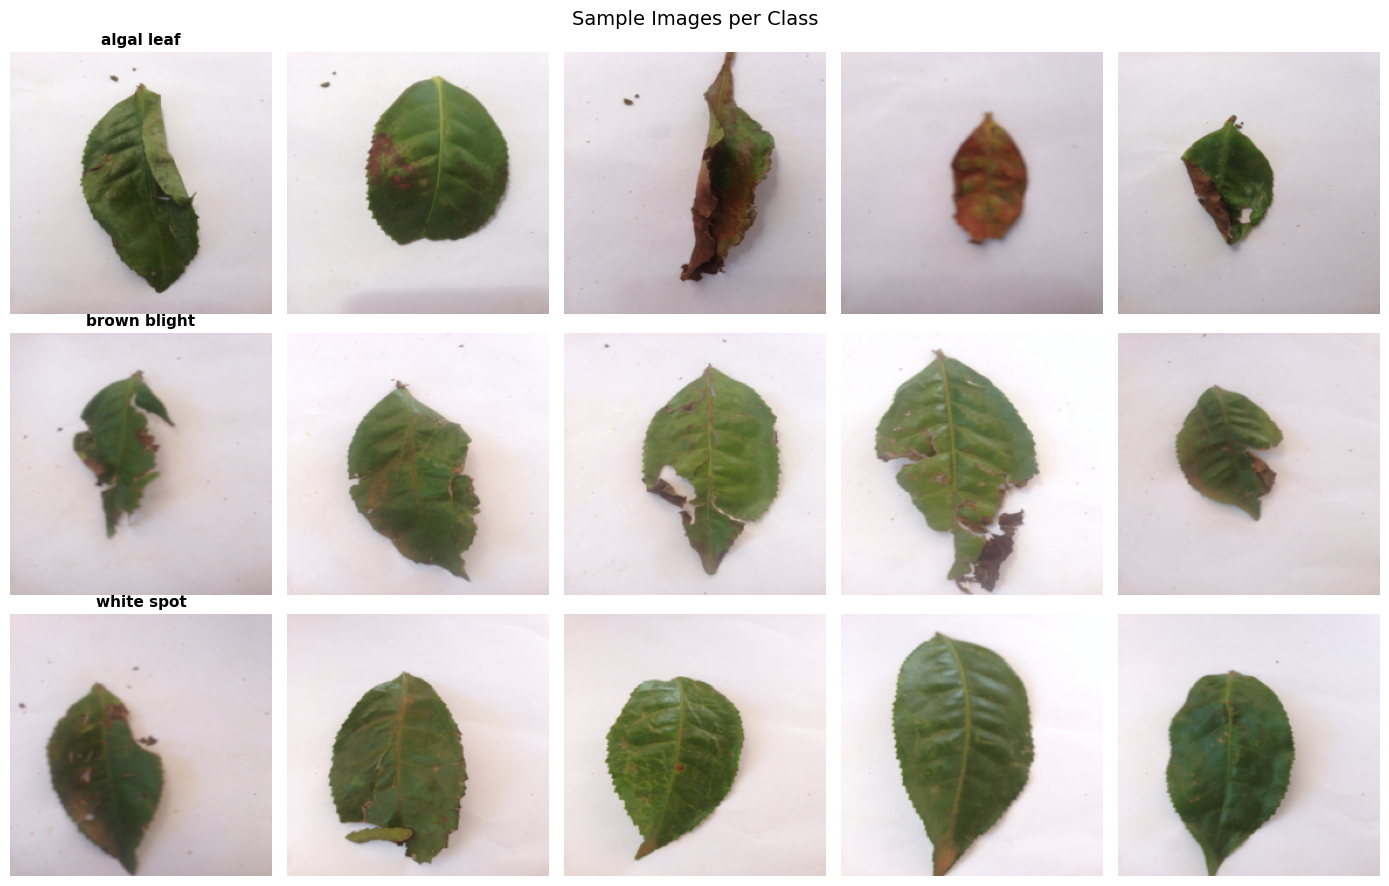

In [6]:
def imshow(img_tensor, title=''):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = IMAGENET_STD * img + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

for row, cls_idx in enumerate(range(3)):
    cls_name = idx_to_class[cls_idx]
    samples  = [img for img, lbl in train_ds.samples if lbl == cls_idx][:5]
    for col, path in enumerate(samples):
        from PIL import Image
        img = eval_transforms(Image.open(path).convert('RGB'))
        axes[row, col].imshow(imshow(img))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls_name, fontsize=11, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=14)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Training Utilities

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += inputs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs    = model(inputs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            preds  = model(inputs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def train_model(model, train_loader, val_loader, num_epochs=30, lr=1e-4, patience=7):
    """Train with early stopping (patience) to prevent overfitting."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history = defaultdict(list)
    best_val_acc  = 0.0
    best_weights  = None
    epochs_no_imp = 0  # early stopping counter

    for epoch in range(num_epochs):
        tr_loss, tr_acc   = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1

        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  '
              f'(no-imp: {epochs_no_imp}/{patience})')

        if epochs_no_imp >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch+1}.')
            break

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
    return history


print('Utilities defined.')


Utilities defined.


## 7. Model 1: VGG16 with Transfer Learning

In [8]:
NUM_CLASSES = 3

# Load pretrained VGG16
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all feature layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# Unfreeze last conv block (block5: features[24:]) for fine-tuning
for param in vgg16.features[24:].parameters():
    param.requires_grad = True

# Replace classifier head with Dropout to reduce overfitting
# Original VGG16 head already has Dropout(0.5) at [0] and [3];
# we add an extra Dropout before the final Linear layer.
in_features = vgg16.classifier[6].in_features
vgg16.classifier[6] = nn.Sequential(
    nn.Dropout(p=0.5),          # extra dropout before final layer
    nn.Linear(in_features, NUM_CLASSES)
)

vgg16 = vgg16.to(DEVICE)

trainable = sum(p.numel() for p in vgg16.parameters() if p.requires_grad)
total     = sum(p.numel() for p in vgg16.parameters())
print(f'VGG16 — Trainable params: {trainable:,} / {total:,}')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 142MB/s]


VGG16 — Trainable params: 126,637,571 / 134,272,835


In [9]:
print('Training VGG16...')
vgg16_history = train_model(vgg16, train_loader, val_loader, num_epochs=25, lr=1e-4)

Training VGG16...
Epoch [01/25]  Train Loss: 1.1322  Train Acc: 0.4086  Val Loss: 1.0246  Val Acc: 0.5094  (no-imp: 0/7)
Epoch [02/25]  Train Loss: 1.0359  Train Acc: 0.5058  Val Loss: 0.9508  Val Acc: 0.6226  (no-imp: 0/7)
Epoch [03/25]  Train Loss: 0.9264  Train Acc: 0.5798  Val Loss: 0.8965  Val Acc: 0.5849  (no-imp: 1/7)
Epoch [04/25]  Train Loss: 0.8099  Train Acc: 0.6848  Val Loss: 0.7644  Val Acc: 0.6604  (no-imp: 0/7)
Epoch [05/25]  Train Loss: 0.7842  Train Acc: 0.7004  Val Loss: 0.7812  Val Acc: 0.6604  (no-imp: 1/7)
Epoch [06/25]  Train Loss: 0.7916  Train Acc: 0.6770  Val Loss: 0.7278  Val Acc: 0.6792  (no-imp: 0/7)
Epoch [07/25]  Train Loss: 0.6831  Train Acc: 0.7626  Val Loss: 0.6150  Val Acc: 0.7925  (no-imp: 0/7)
Epoch [08/25]  Train Loss: 0.6665  Train Acc: 0.7899  Val Loss: 0.6566  Val Acc: 0.7547  (no-imp: 1/7)
Epoch [09/25]  Train Loss: 0.6392  Train Acc: 0.8132  Val Loss: 0.6309  Val Acc: 0.8113  (no-imp: 0/7)
Epoch [10/25]  Train Loss: 0.6613  Train Acc: 0.7782  V

## 8. Model 2: ResNet50 with Transfer Learning

In [10]:
# Load pretrained ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in resnet50.parameters():
    param.requires_grad = False

# Unfreeze layer4 (last residual block) for fine-tuning
for param in resnet50.layer4.parameters():
    param.requires_grad = True

# Replace fc head with Dropout + Linear to reduce overfitting
in_features = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Dropout(p=0.5),          # dropout to combat overfitting
    nn.Linear(in_features, NUM_CLASSES)
)

resnet50 = resnet50.to(DEVICE)

trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet50.parameters())
print(f'ResNet50 — Trainable params: {trainable:,} / {total:,}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


ResNet50 — Trainable params: 14,970,883 / 23,514,179


In [11]:
print('Training ResNet50...')
resnet50_history = train_model(resnet50, train_loader, val_loader, num_epochs=25, lr=1e-4)

Training ResNet50...
Epoch [01/25]  Train Loss: 1.0618  Train Acc: 0.4241  Val Loss: 0.8690  Val Acc: 0.6604  (no-imp: 0/7)
Epoch [02/25]  Train Loss: 0.7789  Train Acc: 0.7510  Val Loss: 0.7861  Val Acc: 0.7170  (no-imp: 0/7)
Epoch [03/25]  Train Loss: 0.7716  Train Acc: 0.7198  Val Loss: 0.7055  Val Acc: 0.7736  (no-imp: 0/7)
Epoch [04/25]  Train Loss: 0.6681  Train Acc: 0.7821  Val Loss: 0.6864  Val Acc: 0.7925  (no-imp: 0/7)
Epoch [05/25]  Train Loss: 0.5905  Train Acc: 0.8521  Val Loss: 0.7642  Val Acc: 0.7170  (no-imp: 1/7)
Epoch [06/25]  Train Loss: 0.5713  Train Acc: 0.8405  Val Loss: 0.6690  Val Acc: 0.7736  (no-imp: 2/7)
Epoch [07/25]  Train Loss: 0.5448  Train Acc: 0.8872  Val Loss: 0.6825  Val Acc: 0.8113  (no-imp: 0/7)
Epoch [08/25]  Train Loss: 0.5414  Train Acc: 0.8716  Val Loss: 0.6418  Val Acc: 0.8679  (no-imp: 0/7)
Epoch [09/25]  Train Loss: 0.5020  Train Acc: 0.8988  Val Loss: 0.7601  Val Acc: 0.7547  (no-imp: 1/7)
Epoch [10/25]  Train Loss: 0.5053  Train Acc: 0.9144

## 9. Training Curves Comparison

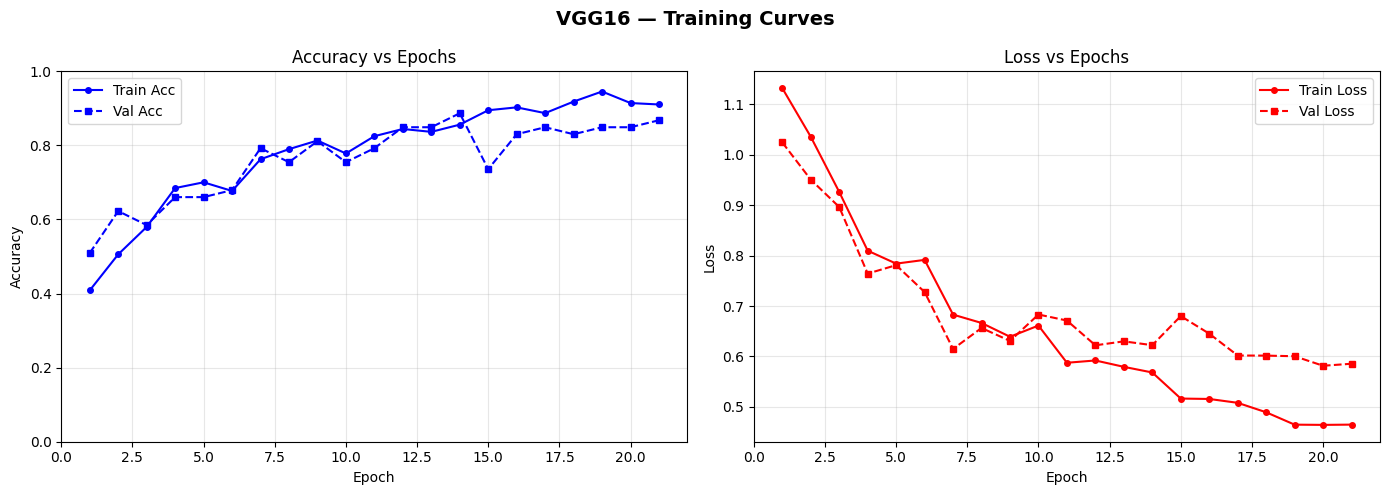

Saved: results/vgg16_training_curves.png


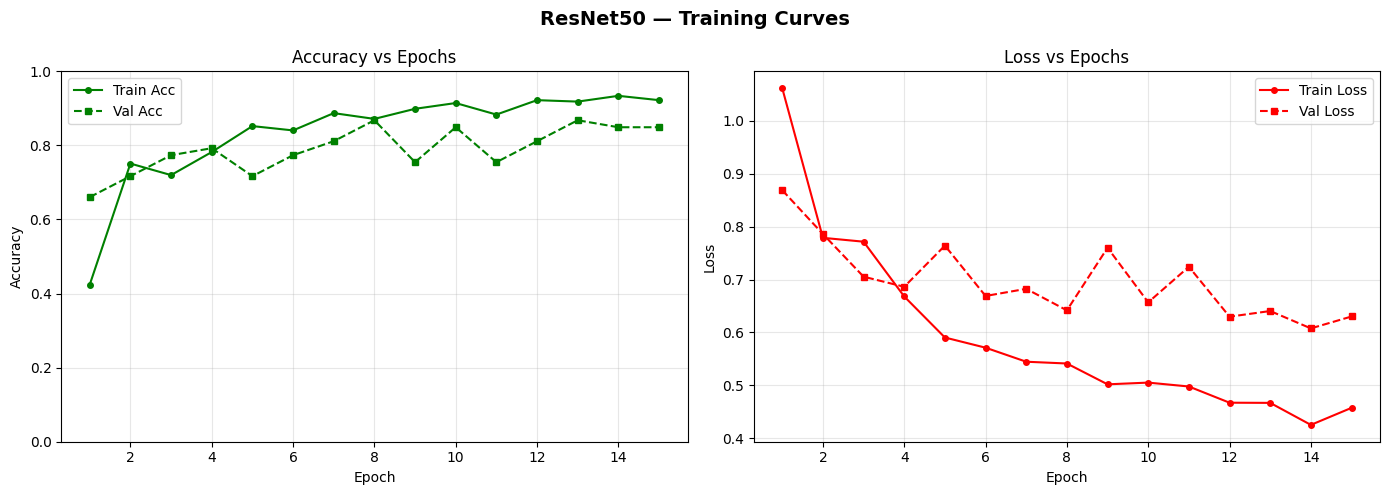

Saved: results/resnet50_training_curves.png


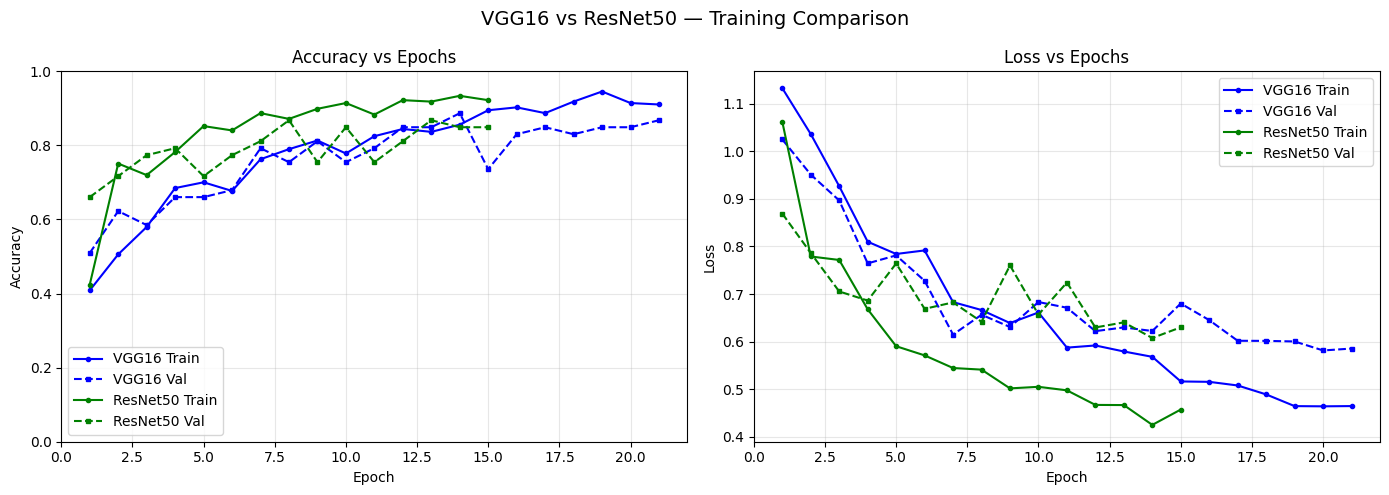

Saved: results/training_curves.png


In [12]:
epochs_vgg    = range(1, len(vgg16_history['train_acc']) + 1)
epochs_resnet = range(1, len(resnet50_history['train_acc']) + 1)

os.makedirs('results', exist_ok=True)

# ── VGG16 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VGG16 — Training Curves', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(epochs_vgg, vgg16_history['train_acc'], 'b-o', markersize=4, label='Train Acc')
ax.plot(epochs_vgg, vgg16_history['val_acc'],   'b--s', markersize=4, label='Val Acc')
ax.set_title('Accuracy vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1]); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_vgg, vgg16_history['train_loss'], 'r-o', markersize=4, label='Train Loss')
ax.plot(epochs_vgg, vgg16_history['val_loss'],   'r--s', markersize=4, label='Val Loss')
ax.set_title('Loss vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/vgg16_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/vgg16_training_curves.png')

# ── ResNet50 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 — Training Curves', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(epochs_resnet, resnet50_history['train_acc'], 'g-o', markersize=4, label='Train Acc')
ax.plot(epochs_resnet, resnet50_history['val_acc'],   'g--s', markersize=4, label='Val Acc')
ax.set_title('Accuracy vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1]); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_resnet, resnet50_history['train_loss'], 'r-o', markersize=4, label='Train Loss')
ax.plot(epochs_resnet, resnet50_history['val_loss'],   'r--s', markersize=4, label='Val Loss')
ax.set_title('Loss vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/resnet50_training_curves.png')

# ── Combined comparison (kept for reference) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VGG16 vs ResNet50 — Training Comparison', fontsize=14)

ax = axes[0]
ax.plot(epochs_vgg,    vgg16_history['train_acc'],    'b-o',  markersize=3, label='VGG16 Train')
ax.plot(epochs_vgg,    vgg16_history['val_acc'],      'b--s', markersize=3, label='VGG16 Val')
ax.plot(epochs_resnet, resnet50_history['train_acc'], 'g-o',  markersize=3, label='ResNet50 Train')
ax.plot(epochs_resnet, resnet50_history['val_acc'],   'g--s', markersize=3, label='ResNet50 Val')
ax.set_title('Accuracy vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1]); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_vgg,    vgg16_history['train_loss'],    'b-o',  markersize=3, label='VGG16 Train')
ax.plot(epochs_vgg,    vgg16_history['val_loss'],      'b--s', markersize=3, label='VGG16 Val')
ax.plot(epochs_resnet, resnet50_history['train_loss'], 'g-o',  markersize=3, label='ResNet50 Train')
ax.plot(epochs_resnet, resnet50_history['val_loss'],   'g--s', markersize=3, label='ResNet50 Val')
ax.set_title('Loss vs Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/training_curves.png')


## 10. Test Set Evaluation

In [13]:
criterion = nn.CrossEntropyLoss()

vgg16_test_loss,    vgg16_test_acc    = evaluate(vgg16,   test_loader, criterion)
resnet50_test_loss, resnet50_test_acc = evaluate(resnet50, test_loader, criterion)

print(f'VGG16   — Test Loss: {vgg16_test_loss:.4f}  Test Accuracy: {vgg16_test_acc:.4f} ({vgg16_test_acc*100:.2f}%)')
print(f'ResNet50 — Test Loss: {resnet50_test_loss:.4f}  Test Accuracy: {resnet50_test_acc:.4f} ({resnet50_test_acc*100:.2f}%)')

VGG16   — Test Loss: 0.4197  Test Accuracy: 0.8621 (86.21%)
ResNet50 — Test Loss: 0.4008  Test Accuracy: 0.8793 (87.93%)


## 11. Confusion Matrices

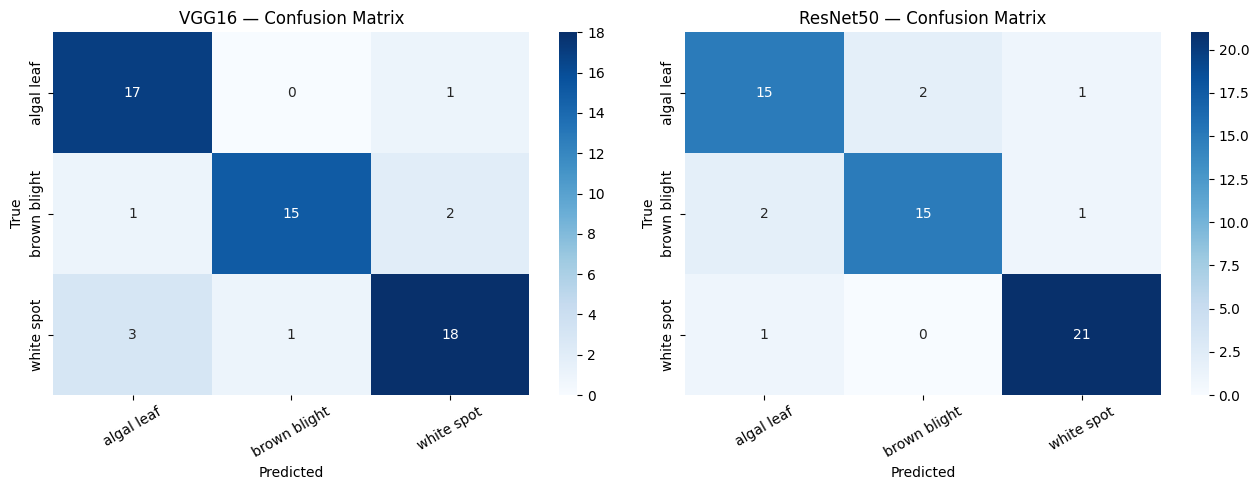

Saved: results/confusion_matrices.png


In [14]:
vgg16_true,   vgg16_pred   = get_predictions(vgg16,   test_loader)
resnet50_true, resnet50_pred = get_predictions(resnet50, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, true, pred, title in [
    (axes[0], vgg16_true,    vgg16_pred,    'VGG16'),
    (axes[1], resnet50_true, resnet50_pred, 'ResNet50'),
]:
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_matrices.png')

## 12. Classification Reports

In [15]:
print('=' * 55)
print('VGG16 Classification Report')
print('=' * 55)
print(classification_report(vgg16_true, vgg16_pred, target_names=CLASS_NAMES))

print('=' * 55)
print('ResNet50 Classification Report')
print('=' * 55)
print(classification_report(resnet50_true, resnet50_pred, target_names=CLASS_NAMES))

VGG16 Classification Report
              precision    recall  f1-score   support

  algal leaf       0.81      0.94      0.87        18
brown blight       0.94      0.83      0.88        18
  white spot       0.86      0.82      0.84        22

    accuracy                           0.86        58
   macro avg       0.87      0.87      0.86        58
weighted avg       0.87      0.86      0.86        58

ResNet50 Classification Report
              precision    recall  f1-score   support

  algal leaf       0.83      0.83      0.83        18
brown blight       0.88      0.83      0.86        18
  white spot       0.91      0.95      0.93        22

    accuracy                           0.88        58
   macro avg       0.88      0.87      0.87        58
weighted avg       0.88      0.88      0.88        58



## 13. Summary Comparison Table

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_dict(true, pred, name):
    return {
        'Model':     name,
        'Accuracy':  f'{accuracy_score(true, pred):.4f}',
        'Precision': f'{precision_score(true, pred, average="weighted"):.4f}',
        'Recall':    f'{recall_score(true, pred, average="weighted"):.4f}',
        'F1-Score':  f'{f1_score(true, pred, average="weighted"):.4f}',
    }

results_df = pd.DataFrame([
    metrics_dict(vgg16_true,    vgg16_pred,    'VGG16'),
    metrics_dict(resnet50_true, resnet50_pred, 'ResNet50'),
])
results_df = results_df.set_index('Model')
print(results_df.to_string())

results_df.to_csv('results/model_comparison.csv')
print('\nSaved: results/model_comparison.csv')

         Accuracy Precision  Recall F1-Score
Model                                       
VGG16      0.8621    0.8673  0.8621   0.8620
ResNet50   0.8793    0.8788  0.8793   0.8787

Saved: results/model_comparison.csv


## 14. Bar Chart — Final Accuracy & Loss

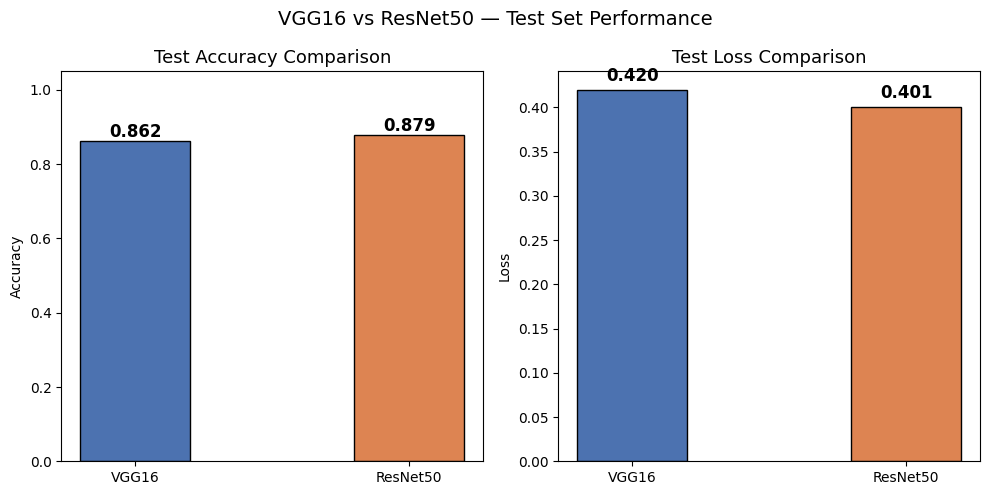

Saved: results/model_comparison_bar.png


In [17]:
models_names = ['VGG16', 'ResNet50']
test_accs    = [vgg16_test_acc, resnet50_test_acc]
test_losses  = [vgg16_test_loss, resnet50_test_loss]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
colors = ['#4C72B0', '#DD8452']

bars1 = ax1.bar(models_names, test_accs, color=colors, edgecolor='black', width=0.4)
ax1.set_ylim(0, 1.05)
ax1.set_title('Test Accuracy Comparison', fontsize=13)
ax1.set_ylabel('Accuracy')
for bar, val in zip(bars1, test_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
             ha='center', fontsize=12, fontweight='bold')

bars2 = ax2.bar(models_names, test_losses, color=colors, edgecolor='black', width=0.4)
ax2.set_title('Test Loss Comparison', fontsize=13)
ax2.set_ylabel('Loss')
for bar, val in zip(bars2, test_losses):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
             ha='center', fontsize=12, fontweight='bold')

plt.suptitle('VGG16 vs ResNet50 — Test Set Performance', fontsize=14)
plt.tight_layout()
plt.savefig('results/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/model_comparison_bar.png')

## 15. Save Models

In [18]:
torch.save(vgg16.state_dict(),   'results/vgg16_tea_leaf.pth')
torch.save(resnet50.state_dict(),'results/resnet50_tea_leaf.pth')
print('Models saved to results/')

Models saved to results/


In [19]:
import shutil
from google.colab import files

shutil.make_archive('results_graphs', 'zip', 'results')
files.download('results_graphs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>